<div style="background:linear-gradient(135deg,#4F46E5,#7E22CE);
color:#fff;padding:32px 34px;border-radius:12px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;">
<div style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.8rem;letter-spacing:.12em;opacity:.85;">
CIENCIA DE DATOS &nbsp;/&nbsp; UNIDAD 2 &nbsp;/&nbsp; 2.4</div>
<div style="font-size:2rem;font-weight:700;line-height:1.15;margin-top:8px;">
Selección y extracción de características</div>
<div style="margin-top:12px;font-size:1rem;opacity:.95;max-width:640px;">
Cuaderno de ejercicios. No todas las columnas ayudan: unas son irrelevantes,
otras redundantes, y demasiadas a la vez perjudican al modelo. Aquí practicamos
cómo <b>quedarnos con lo que importa</b> —seleccionando— o <b>condensar la
información en menos dimensiones</b> —extrayendo con PCA—.</div>
<div style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.78rem;margin-top:18px;opacity:.8;">
M. Sc. Huáscar F. Gonzales G.</div>
</div>

### Cómo usar este cuaderno

Ejecuta las celdas **en orden** (`Shift`+`Enter`). El cuaderno alterna:

- **explicación** breve de cada idea,
- **código demostrativo** listo para correr,

Contenido:
* **2.4.1** Selección de características — filtro, envoltura y embebido
* **2.4.2** Extracción de características — PCA
* **2.4.3** Reducción de dimensionalidad para visualización — t-SNE y UMAP
* **Síntesis** — un mini-pipeline que junta todo

## 0 · Preparación del entorno y los datos

Cargamos las librerías y montamos **dos conjuntos de datos** que usaremos a lo largo del cuaderno.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

**Dataset A — sintético, para *selección*.** Lo fabricamos con `make_classification`
sabiendo de antemano qué columnas sirven. Así podremos **verificar** si cada método
recupera las correctas:

- columnas `f0–f3` → **informativas** (llevan señal real),
- columnas `f4–f5` → **redundantes** (combinaciones de las informativas),
- columnas `f6–f9` → **ruido** (no aportan nada).

<div style="border-left:4px solid #16A34A;background:#F0FDF4;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#16A34A;">IDEA CLAVE</span><br>Tener la <i>respuesta</i> de antemano convierte cada método de selección en un experimento comprobable: ¿encontró las 4 columnas informativas?</div>

In [2]:
from sklearn.datasets import make_classification

X_syn, y_syn = make_classification(
    n_samples=400, n_features=10,
    n_informative=4, n_redundant=2, n_repeated=0,
    n_classes=2, shuffle=False, random_state=42)

cols = [f"f{i}" for i in range(10)]
X_syn_df = pd.DataFrame(X_syn, columns=cols)

VERDAD = {"informativas": [0,1,2,3], "redundantes": [4,5], "ruido": [6,7,8,9]}
print("Dataset A (sintético):", X_syn_df.shape)
print("Columnas informativas reales:", VERDAD["informativas"])
X_syn_df.head(3)

Dataset A (sintético): (400, 10)
Columnas informativas reales: [0, 1, 2, 3]


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9
0,-0.758014,-0.717956,-1.377018,-0.864457,0.648496,0.270602,-0.550692,0.944290,-0.859340,1.142385
1,-0.989471,-0.135112,-1.639859,-0.846797,0.269466,0.348466,-0.009087,0.303123,0.367522,-0.616221
2,-0.036779,-1.158661,-1.925564,-0.588063,0.559911,1.477835,0.389887,-0.772370,-0.502103,0.558691


**Dataset B — Iris, para *extracción* y *visualización*.** El clásico: 4 características (largo/ancho de sépalo y pétalo) y 3 especies. Perfecto para proyectar de 4D a 2D.

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris, y_iris = iris.data, iris.target
print("Dataset B (Iris):", X_iris.shape, "| características:", list(iris.feature_names))
print("Especies:", list(iris.target_names))

Dataset B (Iris): (150, 4) | características: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Especies: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


---
## 2.4.1 · Selección de características

Seleccionar es **escoger un subconjunto** de las características originales y descartar el resto.
Las mismas variables, pero menos. Tres familias se reparten el trabajo:

| Familia | Cómo decide | Balance |
|---|---|---|
| **Filtro** | Estadística por característica, sin modelo | Muy rápido; ignora interacciones |
| **Envoltura** | Prueba subconjuntos con un modelo real | Preciso; costoso |
| **Embebido** | La selección ocurre durante el entrenamiento | Buen término medio |

<div style="border-left:4px solid #7E22CE;background:#FAF5FF;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#7E22CE;">MALDICIÓN DE LA DIMENSIONALIDAD</span><br>Al crecer el número de características, el espacio se vuelve tan vasto que los datos quedan dispersos: las distancias pierden significado y los modelos tienden a <b>sobreajustar</b> (memorizar ruido). Reducir características bien elegidas mejora velocidad, interpretabilidad y, a veces, exactitud.</div>

### Filtro (filter)

Evalúan cada característica con una medida estadística **independiente del modelo**. Son un primer cribado muy rápido.

**Paso 1 — descartar columnas casi constantes** (varianza nula no aporta nada):

In [4]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.0)   # elimina columnas constantes
X_vt = vt.fit_transform(X_syn)
print("Antes:", X_syn.shape, "-> después:", X_vt.shape)
print("(en este dataset ninguna columna es constante, así que no elimina nada)")

Antes: (400, 10) -> después: (400, 10)
(en este dataset ninguna columna es constante, así que no elimina nada)


**Paso 2 — quedarnos con las `k` mejores** según su relación con el objetivo. Para clasificación se usa la **prueba F de ANOVA** (`f_classif`):

In [5]:
from sklearn.feature_selection import SelectKBest, f_classif

sel = SelectKBest(score_func=f_classif, k=4)
X_kbest = sel.fit_transform(X_syn, y_syn)

elegidas = np.where(sel.get_support())[0]
print("Puntajes F por columna:", np.round(sel.scores_, 1))
print("Columnas elegidas (k=4):", list(elegidas))
print("Columnas informativas reales:", VERDAD["informativas"])

Puntajes F por columna: [82.3  0.  51.5  0.1  1.5  0.   0.4  0.2  0.3  2.1]
Columnas elegidas (k=4): [np.int64(0), np.int64(2), np.int64(4), np.int64(9)]
Columnas informativas reales: [0, 1, 2, 3]


<div style="border-left:4px solid #F43F5E;background:#FFF1F2;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#F43F5E;">LO QUE ACABA DE PASAR</span><br>El filtro <b>no</b> recuperó exactamente <code>f0–f3</code>. Mira los puntajes: <code>f1</code> y <code>f3</code> tienen F bajo. ¿Por qué? El test F mide cada columna <b>por separado</b>, y algunas features solo son informativas <b>en combinación</b> con otras. Esta es la gran limitación del filtro: ignora las interacciones. En un momento veremos que el envoltorio sí las encuentra.</div>

<div style="border-left:4px solid #6B7280;background:#F9FAFB;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#6B7280;">NOTA</span><br>Para variables <b>categóricas</b> se usa <code>chi2</code>; para relaciones <b>no lineales</b>, <code>mutual_info_classif</code> (información mutua), que capta dependencias que la correlación lineal no ve.</div>

#### ✏️ Ejercicio 1 — Información mutua

La prueba F solo detecta relaciones **lineales**. Usa `mutual_info_classif` para puntuar las 10 columnas del dataset sintético y responde: ¿coincide su top-4 con las columnas informativas reales (`f0–f3`)? Completa la celda:

In [6]:
# Solución
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_syn, y_syn, random_state=42)
top4 = np.argsort(mi)[::-1][:4]

print("MI por columna:", np.round(mi, 3))
print("Top-4 por MI:", sorted(top4.tolist()), "| reales:", VERDAD["informativas"])
print("\nLa MI tampoco es perfecta aquí, pero al ser univariada comparte la misma\n"
      "debilidad que el test F: evalúa cada columna aislada de las demás.")

MI por columna: [0.123 0.061 0.06  0.    0.019 0.073 0.    0.    0.023 0.   ]
Top-4 por MI: [0, 1, 2, 5] | reales: [0, 1, 2, 3]

La MI tampoco es perfecta aquí, pero al ser univariada comparte la misma
debilidad que el test F: evalúa cada columna aislada de las demás.


### Envoltura (wrapper)

Usan un **modelo real** para evaluar subconjuntos de características. Más precisos, más costosos. El clásico es **RFE** (*Recursive Feature Elimination*): entrena, descarta la menos importante y repite.

In [7]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

rfe = RFE(estimator=LogisticRegression(max_iter=1000),
          n_features_to_select=4)
rfe.fit(X_syn, y_syn)

print("Columnas elegidas por RFE:", list(np.where(rfe.support_)[0]))
print("Ranking (1 = elegida; >1 = orden de descarte):", rfe.ranking_)
print("Columnas informativas reales:", VERDAD["informativas"])

Columnas elegidas por RFE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Ranking (1 = elegida; >1 = orden de descarte): [1 1 1 1 6 4 3 7 5 2]
Columnas informativas reales: [0, 1, 2, 3]


<div style="border-left:4px solid #16A34A;background:#F0FDF4;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#16A34A;">EL CONTRASTE CLAVE</span><br>RFE recupera <b>exactamente</b> <code>f0–f3</code>, ¡las 4 informativas! Donde el filtro univariado fallaba, el envoltorio acierta, porque evalúa las columnas <b>juntas</b> usando un modelo real. Ese es el precio-beneficio: más cómputo a cambio de captar interacciones.</div>

#### ✏️ Ejercicio 2 — Leyendo el `ranking_`

Ejecuta RFE pidiendo **solo 2** características (`n_features_to_select=2`). Luego, usando `ranking_`, indica **cuál fue la primera columna en ser descartada** (la que tiene el ranking más alto).

In [8]:
# Solución
rfe2 = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=2)
rfe2.fit(X_syn, y_syn)

elegidas2 = list(np.where(rfe2.support_)[0])
peor = int(np.argmax(rfe2.ranking_))
print("Elegidas (k=2):", elegidas2)
print("Ranking:", rfe2.ranking_)
print("Primera columna descartada (ranking más alto):", peor)

Elegidas (k=2): [np.int64(0), np.int64(2)]
Ranking: [1 3 1 2 8 6 5 9 7 4]
Primera columna descartada (ranking más alto): 7


### Embebido (embedded)

La selección ocurre **durante** el entrenamiento del modelo. Dos casos clásicos: la **importancia de características** de los árboles y la regularización **Lasso (L1)**.

**Importancia de características + `SelectFromModel`.** Un `RandomForest` mide cuánto aporta cada columna; luego conservamos las de importancia por encima de un umbral (la mediana):

Columnas conservadas (importancia >= mediana): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5)]
Forma resultante: (400, 5)


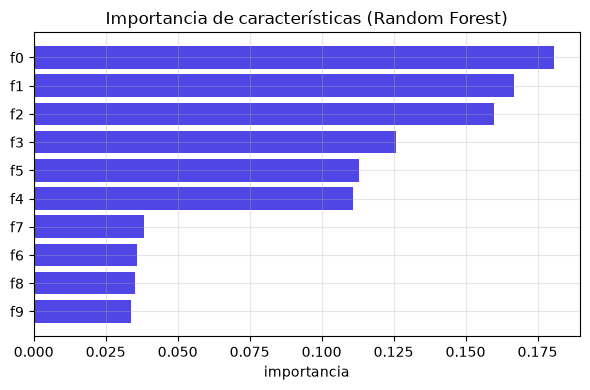

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf = RandomForestClassifier(random_state=42).fit(X_syn, y_syn)
imp = rf.feature_importances_

sel_rf = SelectFromModel(rf, threshold="median", prefit=True)
X_rf = sel_rf.transform(X_syn)
print("Columnas conservadas (importancia >= mediana):", list(np.where(sel_rf.get_support())[0]))
print("Forma resultante:", X_rf.shape)

# Visualizamos las importancias
orden = np.argsort(imp)
plt.barh([cols[i] for i in orden], imp[orden], color="#4F46E5")
plt.title("Importancia de características (Random Forest)")
plt.xlabel("importancia"); plt.tight_layout(); plt.show()

**Lasso (penalización L1).** La regularización L1 empuja a **cero** los coeficientes de las variables inútiles; las que sobreviven son las seleccionadas. En la API actual de scikit-learn se pide L1 puro con `l1_ratio=1` y el solver `saga`:

In [10]:
# L1 sobre una regresión logística: los coeficientes en 0 quedan descartados
l1 = LogisticRegression(solver="saga", l1_ratio=1, C=0.1, max_iter=5000)
l1.fit(X_syn, y_syn)

coef = l1.coef_.ravel()
sobreviven = np.where(np.abs(coef) > 1e-6)[0]
print("Coeficientes L1:", np.round(coef, 3))
print("Columnas con coeficiente != 0 (seleccionadas):", list(sobreviven))

Coeficientes L1: [ 0.866 -0.145  0.711  0.421  0.     0.     0.     0.     0.     0.031]
Columnas con coeficiente != 0 (seleccionadas): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(9)]


#### ✏️ Ejercicio 3 — Regularización más fuerte

En Lasso, un `C` **más pequeño** significa regularización más fuerte → más coeficientes a cero. Reentrena con `C=0.02` y compara cuántas columnas sobreviven frente a `C=0.1`.

In [11]:
# ✅ Solución
l1_fuerte = LogisticRegression(solver="saga", l1_ratio=1, C=0.02, max_iter=5000)
l1_fuerte.fit(X_syn, y_syn)
sob_fuerte = np.where(np.abs(l1_fuerte.coef_.ravel()) > 1e-6)[0]

print(f"C=0.10  -> {len(sobreviven)} columnas: {list(sobreviven)}")
print(f"C=0.02  -> {len(sob_fuerte)} columnas: {list(sob_fuerte)}")
print("\nMás regularización (C menor) = modelo más disperso = menos columnas.")

C=0.10  -> 5 columnas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(9)]
C=0.02  -> 2 columnas: [np.int64(0), np.int64(2)]

Más regularización (C menor) = modelo más disperso = menos columnas.


### Resumen de la selección

Las tres familias probadas sobre el **mismo** dataset:

| Familia | Método usado | ¿Recuperó las informativas? |
|---|---|---|
| Filtro | `SelectKBest(f_classif)` | Parcial — ignora interacciones |
| Envoltura | `RFE(LogisticRegression)` | Sí, exacto |
| Embebido | `RandomForest` / `Lasso L1` | Sí, con algo de ruido residual |

<div style="border-left:4px solid #6B7280;background:#F9FAFB;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#6B7280;">CÓMO ELEGIR</span><br>Si necesitas <b>explicar</b> qué variables influyen (ante un cliente o un tribunal), prefiere <b>selección</b> — sabes qué columnas quedaron. Si solo te importa comprimir para que el modelo funcione mejor o para visualizar, la <b>extracción</b> (siguiente sección) suele ser más potente.</div>

---
## 2.4.2 · Extracción de características: PCA

Cuando en vez de **descartar** columnas queremos **condensarlas**, usamos extracción.
El **Análisis de Componentes Principales (PCA)** crea variables nuevas —los *componentes
principales*— como combinaciones de las originales, ordenadas para que las primeras
capturen la mayor parte de la variación.

<div style="border-left:4px solid #7E22CE;background:#FAF5FF;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#7E22CE;">PCA</span><br>Rota los ejes del espacio de datos para alinearlos con las direcciones de <b>máxima varianza</b>. El primer componente es la dirección donde los datos más se dispersan; el segundo, la siguiente (perpendicular al primero); etc. Conservando solo los primeros, reducimos dimensiones perdiendo la menor información posible.</div>

<div style="border-left:4px solid #F43F5E;background:#FFF1F2;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#F43F5E;">ESCALAR ES OBLIGATORIO</span><br>PCA se basa en la varianza, y la varianza depende de las unidades. Si una columna está en miles (salario) y otra en decenas (edad), PCA creerá que la primera es <i>más importante</i> solo por su escala. Aplica siempre <code>StandardScaler</code> <b>antes</b> de PCA.</div>

### PCA en la práctica: Iris de 4D a 2D

Proyectamos las 4 características de Iris a 2 dimensiones y medimos cuánta información conservamos:

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_esc = StandardScaler().fit_transform(X_iris)   # 1) escalar primero
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_esc)                 # 2) 4 columnas -> 2 componentes

evr = pca.explained_variance_ratio_
print("Varianza explicada por componente:", np.round(evr, 4))
print(f"Total conservado con 2 componentes: {evr.sum():.1%}")

Varianza explicada por componente: [0.7296 0.2285]
Total conservado con 2 componentes: 95.8%


<div style="border-left:4px solid #7E22CE;background:#FAF5FF;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#7E22CE;">VARIANZA EXPLICADA (explained_variance_ratio_)</span><br>Proporción de la variación total que captura cada componente. Es la brújula para decidir cuántos conservar: aquí, <b>2 de 4</b> componentes retienen ~96% de la información.</div>

Al graficar esos dos componentes, las tres especies se separan con notable claridad **a pesar de haber pasado de 4D a 2D**:

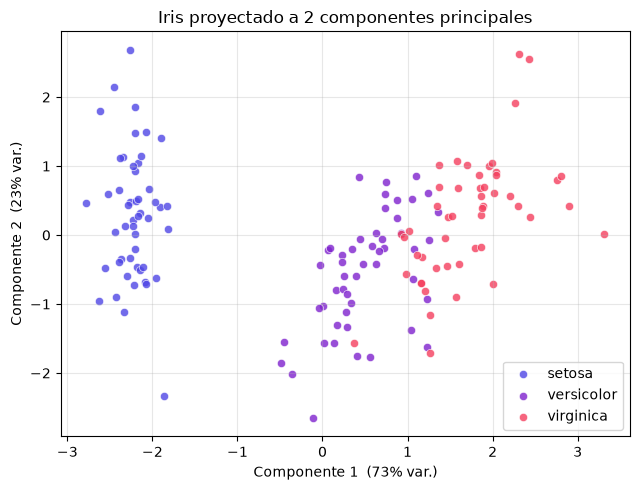

In [13]:
colores = ["#4F46E5", "#7E22CE", "#F43F5E"]
plt.figure(figsize=(6.5, 5))
for clase, nombre in enumerate(iris.target_names):
    m = y_iris == clase
    plt.scatter(X_pca[m, 0], X_pca[m, 1], c=colores[clase], label=nombre,
                s=35, alpha=0.8, edgecolor="white", linewidth=0.5)
plt.xlabel(f"Componente 1  ({evr[0]:.0%} var.)")
plt.ylabel(f"Componente 2  ({evr[1]:.0%} var.)")
plt.title("Iris proyectado a 2 componentes principales")
plt.legend(); plt.tight_layout(); plt.show()

### ¿Cuántos componentes conservar?

La estrategia habitual: mirar la **varianza acumulada** y quedarse con los componentes necesarios para alcanzar un umbral (p. ej. 95%). El **scree plot** lo hace evidente:

Varianza acumulada: [0.73 0.96 0.99 1.  ]


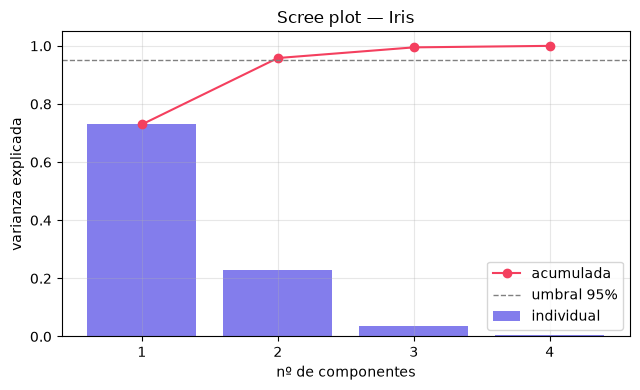

In [14]:
pca_full = PCA().fit(X_esc)
evr_full = pca_full.explained_variance_ratio_
acum = np.cumsum(evr_full)
print("Varianza acumulada:", np.round(acum, 2))

x = np.arange(1, len(evr_full) + 1)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(x, evr_full, color="#4F46E5", alpha=0.7, label="individual")
ax.plot(x, acum, "o-", color="#F43F5E", label="acumulada")
ax.axhline(0.95, ls="--", color="gray", lw=1, label="umbral 95%")
ax.set_xlabel("nº de componentes"); ax.set_ylabel("varianza explicada")
ax.set_xticks(x); ax.set_title("Scree plot — Iris"); ax.legend()
plt.tight_layout(); plt.show()

<div style="border-left:4px solid #6B7280;background:#F9FAFB;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#6B7280;">EL PRECIO DE PCA</span><br>Los componentes son combinaciones matemáticas de las variables originales, así que pierden significado directo: <i>Componente 1</i> no es una magnitud del mundo real como <i>ancho de pétalo</i>. Ganamos compresión a cambio de interpretabilidad — el compromiso central de la extracción.</div>

#### ✏️ Ejercicio 4 — PCA sobre datos de dimensión alta

El dataset **breast cancer** tiene **30 características**. Escálalo, ajusta un PCA completo y encuentra el **número mínimo de componentes** necesarios para conservar al menos el **95%** de la varianza. *Pista:* `np.argmax(acumulada >= 0.95) + 1`.

In [15]:
from sklearn.datasets import load_breast_cancer
Xbc, ybc = load_breast_cancer(return_X_y=True)

# Solución
Xbc_esc = StandardScaler().fit_transform(Xbc)
pca_bc = PCA().fit(Xbc_esc)
acum_bc = np.cumsum(pca_bc.explained_variance_ratio_)
n_comp = int(np.argmax(acum_bc >= 0.95) + 1)

print(f"De {Xbc.shape[1]} características -> {n_comp} componentes conservan el 95% de la varianza")
print(f"Reducción del {(1 - n_comp/Xbc.shape[1]):.0%} en el número de dimensiones.")

De 30 características -> 10 componentes conservan el 95% de la varianza
Reducción del 67% en el número de dimensiones.


---
## 2.4.3 · Reducción de dimensionalidad para visualización

PCA es **lineal**: proyecta rotando ejes rectos. Cuando la estructura de los datos es
compleja y curva, hay métodos **no lineales** pensados específicamente para *ver* datos
de alta dimensión en 2D, revelando agrupamientos que PCA podría no mostrar.

<div style="border-left:4px solid #F43F5E;background:#FFF1F2;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#F43F5E;">CÓMO (NO) LEER UN GRÁFICO t-SNE</span><br>• Solo sirve para <b>visualizar</b>: no se usa como entrada de un modelo.<br>• El tamaño de los grupos y las distancias entre ellos <b>no</b> son literales; solo importa qué puntos se agrupan con cuáles.<br>• Es <b>estocástico</b>: cada corrida difiere. Fija <code>random_state</code> y prueba varios <code>perplexity</code>.</div>

### t-SNE

*t-distributed Stochastic Neighbor Embedding*: coloca los puntos en 2D procurando que los vecinos del espacio original sigan cerca. Excelente para descubrir grupos.

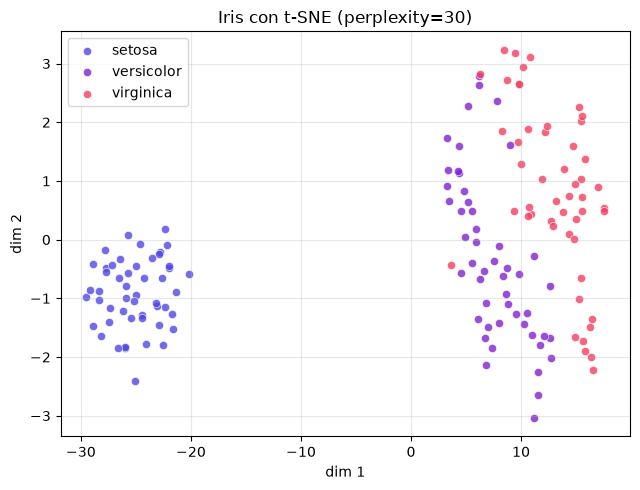

In [16]:
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_esc)

plt.figure(figsize=(6.5, 5))
for clase, nombre in enumerate(iris.target_names):
    m = y_iris == clase
    plt.scatter(X_tsne[m, 0], X_tsne[m, 1], c=colores[clase], label=nombre,
                s=35, alpha=0.8, edgecolor="white", linewidth=0.5)
plt.title("Iris con t-SNE (perplexity=30)")
plt.xlabel("dim 1"); plt.ylabel("dim 2")
plt.legend(); plt.tight_layout(); plt.show()

### UMAP

*Uniform Manifold Approximation and Projection*: objetivo similar, pero suele ser **más rápido** y preservar mejor la **estructura global**. No viene en scikit-learn; se instala aparte (`pip install umap-learn`). La celda lo intenta y, si no está instalado, lo indica sin romperse:

In [17]:
try:
    import umap
    reductor = umap.UMAP(n_components=2, random_state=42)
    X_umap = reductor.fit_transform(X_esc)

    plt.figure(figsize=(6.5, 5))
    for clase, nombre in enumerate(iris.target_names):
        m = y_iris == clase
        plt.scatter(X_umap[m, 0], X_umap[m, 1], c=colores[clase], label=nombre,
                    s=35, alpha=0.8, edgecolor="white", linewidth=0.5)
    plt.title("Iris con UMAP"); plt.legend(); plt.tight_layout(); plt.show()
except ImportError:
    print("UMAP no está instalado. Para usarlo, ejecuta en una celda:")
    print("    !pip install umap-learn")

UMAP no está instalado. Para usarlo, ejecuta en una celda:
    !pip install umap-learn


| | PCA | t-SNE / UMAP |
|---|---|---|
| **Tipo** | Lineal | No lineal |
| **Uso principal** | Comprimir para modelar o visualizar | Visualizar agrupamientos |
| **¿Alimentar un modelo?** | Sí, es habitual | No; solo exploración visual |
| **Determinista** | Sí | No (depende de la semilla) |

#### ✏️ Ejercicio 5 — El efecto de `perplexity`

`perplexity` controla cuántos vecinos considera t-SNE. Genera t-SNE con **tres** valores (`5`, `30`, `50`) y grafícalos lado a lado. Observa cómo cambia la forma de los grupos aunque los datos sean los mismos.

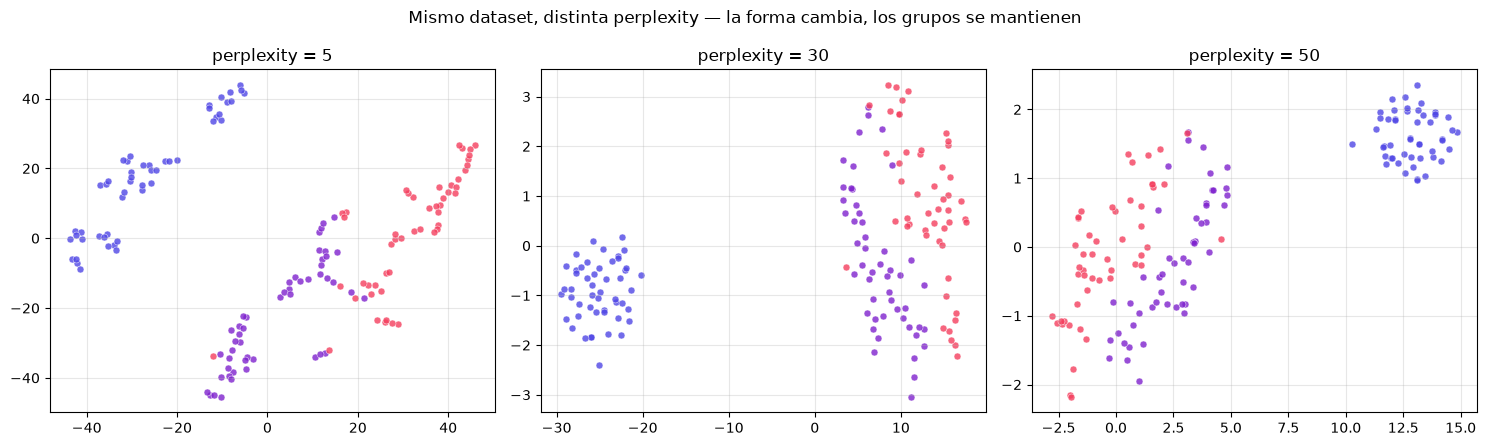

In [18]:
# ✅ Solución
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, p in zip(axes, [5, 30, 50]):
    emb = TSNE(n_components=2, perplexity=p, random_state=42).fit_transform(X_esc)
    for clase in range(3):
        m = y_iris == clase
        ax.scatter(emb[m, 0], emb[m, 1], c=colores[clase], s=25, alpha=0.8,
                   edgecolor="white", linewidth=0.4)
    ax.set_title(f"perplexity = {p}")
fig.suptitle("Mismo dataset, distinta perplexity — la forma cambia, los grupos se mantienen")
plt.tight_layout(); plt.show()

---
## Síntesis · Un mini-pipeline que junta todo

Ante demasiadas características tienes dos caminos:

- **Selección** — conserva un subconjunto de las variables originales (filtro / envoltura / embebido) y **mantiene la interpretabilidad**.
- **Extracción** — crea variables nuevas más compactas: **PCA** para comprimir (recordando escalar y mirar la varianza explicada), y **t-SNE / UMAP** para visualizar estructuras complejas.

<div style="border-left:4px solid #16A34A;background:#F0FDF4;padding:12px 16px;margin:10px 0;border-radius:4px;font-family:'IBM Plex Sans','Segoe UI',system-ui,sans-serif;color:#111827;"><span style="font-family:'IBM Plex Mono','Consolas',monospace;font-size:.72rem;letter-spacing:.08em;font-weight:700;color:#16A34A;">LA REGLA DE FONDO</span><br>Igual que en todo el preprocesamiento: <b>aprende los parámetros solo del entrenamiento</b> y aplica la misma transformación al resto. Por eso todo va dentro de un <code>Pipeline</code> y se ajusta con los datos de <code>train</code>.</div>

#### Ejercicio final — Comparar estrategias con un clasificador real

Sobre **breast cancer**, entrena una regresión logística de tres formas y compara su exactitud en test:

1. **Todas** las 30 características (línea base).
2. **Selección**: las 10 mejores con `SelectKBest`.
3. **Extracción**: PCA reteniendo el 95% de la varianza.

Todo dentro de un `Pipeline` (escalado incluido) y evaluado con `train_test_split`.

In [19]:
# Solución
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

Xtr, Xte, ytr, yte = train_test_split(Xbc, ybc, test_size=0.3,
                                      stratify=ybc, random_state=42)

base = make_pipeline(StandardScaler(),
                     LogisticRegression(max_iter=5000))
seleccion = make_pipeline(StandardScaler(),
                          SelectKBest(f_classif, k=10),
                          LogisticRegression(max_iter=5000))
extraccion = make_pipeline(StandardScaler(),
                           PCA(n_components=0.95),
                           LogisticRegression(max_iter=5000))

for nombre, pipe in [("Todas (30 cols)", base),
                     ("Selección KBest (10)", seleccion),
                     ("PCA (95% var.)", extraccion)]:
    pipe.fit(Xtr, ytr)
    print(f"{nombre:24s} -> exactitud en test: {pipe.score(Xte, yte):.3f}")

print("\nMoraleja: reducir de 30 columnas casi no cuesta exactitud —y a veces la mejora—,\n"
      "ganando velocidad e interpretabilidad. Eso es exactamente lo que buscábamos.")

Todas (30 cols)          -> exactitud en test: 0.988
Selección KBest (10)     -> exactitud en test: 0.936
PCA (95% var.)           -> exactitud en test: 0.971

Moraleja: reducir de 30 columnas casi no cuesta exactitud —y a veces la mejora—,
ganando velocidad e interpretabilidad. Eso es exactamente lo que buscábamos.
